In [6]:
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz

import gdown

gdown.download("https://drive.google.com/uc?id=1e-ngCf34IO8zgK0512hLV9oFjPWDP1Nd", "flowers_icml.tar.gz", quiet=False)

--2025-02-21 15:19:06--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz [following]
--2025-02-21 15:19:07--  https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344862509 (329M) [application/octet-stream]
Saving to: ‘102flowers.tgz.1’

102flowers.tgz.1    100%[===================>] 328.89M  27.5MB/s    in 13s     

2025-02-21 15:19:21 (24.7 MB/s) - ‘102flowers.tgz.1’ saved [344862509/344862509]



Downloading...
From (original): https://drive.google.com/uc?id=1e-ngCf34IO8zgK0512hLV9oFjPWDP1Nd
From (redirected): https://drive.google.com/uc?id=1e-ngCf34IO8zgK0512hLV9oFjPWDP1Nd&confirm=t&uuid=04096ec8-fee2-414e-b027-81083965434a
To: /kaggle/working/flowers_icml.tar.gz
100%|██████████| 785M/785M [00:08<00:00, 92.3MB/s] 


'flowers_icml.tar.gz'

In [ ]:
import tarfile
import os

In [7]:
if not os.path.exists("data/flowers"):
    with tarfile.open("102flowers.tgz", "r:gz") as tar:
        tar.extractall("data/flowers")

if not os.path.exists("data/captions"):
    with tarfile.open("flowers_icml.tar.gz", "r:gz") as tar:
        tar.extractall("data/captions")

In [14]:
!pip install torchfile

  Preparing metadata (setup.py) ... done
  Created wheel for torchfile: filename=torchfile-0.1.0-py3-none-any.whl size=5693 sha256=af0dc4ae8e72d6c0cbadea5c8e16e3971d04cd49a24b11ac26e6695ae9e86069
  Stored in directory: /root/.cache/pip/wheels/c7/e9/87/1c51daf8e468d5c14931f8ac3344880f903ba96b063675cac2
Successfully built torchfile


In [ ]:
import os
import tarfile
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torchfile

Selected Train Classes: ['class_00001', 'class_00002', 'class_00003', 'class_00010', 'class_00016', 'class_00025', 'class_00030', 'class_00032', 'class_00045', 'class_00053', 'class_00063', 'class_00070', 'class_00072', 'class_00079', 'class_00081', 'class_00082', 'class_00083', 'class_00091', 'class_00093', 'class_00094']
Selected Test Classes: ['class_00048', 'class_00050', 'class_00067', 'class_00090', 'class_00099']
Train dataset size: 1476
Test dataset size: 350
torch.Size([3, 64, 64])


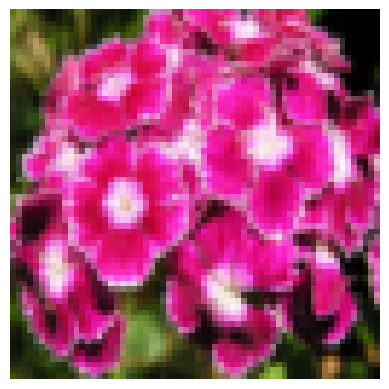

Models defined successfully!


In [14]:
torch.manual_seed(42)
np.random.seed(42)

# Step 1: Extract dataset
def extract_datasets():
    if not os.path.exists("data/flowers"):
        with tarfile.open("102flowers.tgz", "r:gz") as tar:
            tar.extractall("data/flowers")
    if not os.path.exists("data/captions"):
        with tarfile.open("flowers_icml.tar.gz", "r:gz") as tar:
            tar.extractall("data/captions")

extract_datasets()

with open("data/captions/flowers_icml/allclasses.txt", "r") as f:
    all_classes = [line.strip() for line in f.readlines()]

# Randomly select 20 train classes and 5 test classes
train_classes = set(random.sample(all_classes, 20))
test_classes = set(random.sample(list(set(all_classes) - train_classes), 5))

print(f"Selected Train Classes: {sorted(train_classes)}")
print(f"Selected Test Classes: {sorted(test_classes)}")

# Dataset class
class FlowerDataset(Dataset):
    def __init__(self, image_dir, caption_dir, selected_classes, transform=None):
        self.image_dir = image_dir
        self.caption_dir = caption_dir
        self.transform = transform
        self.image_files = []
        self.captions = {}

        # Load image files and corresponding captions from selected classes
        for class_name in selected_classes:
            class_path = os.path.join(caption_dir, "flowers_icml", class_name)
            if os.path.isdir(class_path):
                for caption_file in os.listdir(class_path):
                    image_id = caption_file.replace(".t7", "")
                    image_filename = f"{image_id}.jpg"
                    image_path = os.path.join(image_dir, "jpg", image_filename)
                    if os.path.exists(image_path):
                        self.image_files.append(image_path)
                        caption_data = torchfile.load(os.path.join(class_path, caption_file))
                        
                        if isinstance(caption_data, dict):
                            if b'txt' in caption_data:
                                caption_tensor = torch.tensor(caption_data[b'txt'], dtype=torch.float32)
                            else:
                                raise ValueError(f"Unexpected dict structure in {caption_file}: {caption_data.keys()}")
                        elif isinstance(caption_data, list):
                            caption_tensor = torch.tensor(caption_data[0], dtype=torch.float32)
                        elif isinstance(caption_data, np.ndarray):
                            caption_tensor = torch.tensor(caption_data, dtype=torch.float32)
                        elif isinstance(caption_data, torch.Tensor):
                            caption_tensor = caption_data
                        else:
                            raise TypeError(f"Unsupported caption format: {type(caption_data)} in {caption_file}")
                        
                        self.captions[image_id] = caption_tensor
    
    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        image_id = os.path.basename(image_path).replace(".jpg", "")
        text_embedding = self.captions.get(image_id, torch.zeros(256))
        return image, text_embedding

# Define transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Create datasets and dataloaders
train_dataset = FlowerDataset("data/flowers", "data/captions", train_classes, transform=transform)
test_dataset = FlowerDataset("data/flowers", "data/captions", test_classes, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


# Define models

class SourceEncoder(nn.Module):
    def __init__(self):
        super(SourceEncoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc = nn.Linear(256*8*8, 128)
    
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.text_projection = nn.Linear(1024, 128)
        self.fc = nn.Linear(256, 256*8*8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
    
    def forward(self, img_repr, text_repr):
        text_repr = self.text_projection(text_repr)
        x = torch.cat((img_repr, text_repr), dim=1)
        x = self.fc(x).view(-1, 256, 8, 8)
        return self.deconv(x)

        
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_dim=128):
        super(Discriminator, self).__init__()
        
        # CNN Feature Extractor for Image
        self.conv_layers = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )

        self.fc = nn.Linear(8192 + feature_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, img, feature):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)
        x = torch.cat((x, feature), dim=1)
        x = self.fc(x)
        return self.sigmoid(x)


source_encoder = SourceEncoder()
generator = Generator()
discriminator = Discriminator()

print("Models defined successfully!")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from tqdm import tqdm

In [19]:
def train_model(source_encoder, generator, discriminator, dataloader, num_epochs=120, save_dir="checkpoints"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    criterion_GAN = nn.BCELoss()
    criterion_L1 = nn.L1Loss()
    
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_SE = optim.Adam(source_encoder.parameters(), lr=0.0002, betas=(0.5, 0.999))

    source_encoder.to(device)
    generator.to(device)
    discriminator.to(device)

    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(1, num_epochs + 1):
        running_D_loss, running_G_loss = 0.0, 0.0
        progress_bar = tqdm(dataloader, desc=f"Epoch [{epoch}/{num_epochs}]", leave=False)
        
        for images, text_embeddings in progress_bar:
            images = images.to(device)
            text_embeddings = text_embeddings[:, torch.randint(0, 10, (1,)).item(), :]

            text_embeddings = text_embeddings.to(device)

            optimizer_SE.zero_grad()
            source_features = source_encoder(images)
            optimizer_SE.step()
            
            # Train Discriminator
            optimizer_D.zero_grad()
            real_outputs = discriminator(images, source_features.detach())
            fake_images = generator(source_features.detach(), text_embeddings)
            fake_outputs = discriminator(fake_images.detach(), source_features.detach())
            
            D_real_loss = criterion_GAN(real_outputs, torch.ones_like(real_outputs))
            D_fake_loss = criterion_GAN(fake_outputs, torch.zeros_like(fake_outputs))
            D_loss = (D_real_loss + D_fake_loss) * 0.5
            D_loss.backward()
            optimizer_D.step()
            
            # Train Generator
            optimizer_G.zero_grad()
            fake_images = generator(source_features, text_embeddings)
            fake_outputs = discriminator(fake_images, source_features)
            
            G_loss = criterion_GAN(fake_outputs, torch.ones_like(fake_outputs)) + 0.1 * criterion_L1(fake_images, images)
            G_loss.backward(retain_graph=True)
            optimizer_G.step()
            
            running_D_loss += D_loss.item()
            running_G_loss += G_loss.item()
            progress_bar.set_postfix(D_Loss=D_loss.item(), G_Loss=G_loss.item())
        
        print(f"Epoch [{epoch}/{num_epochs}] - D Loss: {running_D_loss/len(dataloader):.5f} | G Loss: {running_G_loss/len(dataloader):.5f}")

        if epoch % 10 == 0:
            torch.save(generator.state_dict(), os.path.join(save_dir, f"generator_epoch_{epoch}.pth"))
            torch.save(discriminator.state_dict(), os.path.join(save_dir, f"discriminator_epoch_{epoch}.pth"))
            torch.save(source_encoder.state_dict(), os.path.join(save_dir, f"source_encoder_epoch_{epoch}.pth"))
    
    print("Training complete!")


In [20]:
train_model(source_encoder, generator, discriminator, train_loader)

Epoch [1/120] - D Loss: 0.38149 | G Loss: 4.01777


Epoch [2/120] - D Loss: 0.33892 | G Loss: 5.03184


Epoch [3/120] - D Loss: 0.33436 | G Loss: 4.05443


Epoch [4/120] - D Loss: 0.39613 | G Loss: 4.40319


Epoch [5/120] - D Loss: 0.36512 | G Loss: 4.35775


...

Epoch [116/120] - D Loss: 0.21670 | G Loss: 6.03240


Epoch [117/120] - D Loss: 0.15633 | G Loss: 5.39996


Epoch [118/120] - D Loss: 0.17157 | G Loss: 5.87313


Epoch [119/120] - D Loss: 0.20345 | G Loss: 5.56572


Epoch [120/120] - D Loss: 0.23538 | G Loss: 5.27122
Training complete!


In [22]:
# Load trained models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
source_encoder = SourceEncoder().to(device)
discriminator = Discriminator().to(device)

generator.load_state_dict(torch.load("checkpoints/generator_epoch_120.pth", map_location=device))
source_encoder.load_state_dict(torch.load("checkpoints/source_encoder_epoch_120.pth", map_location=device))
discriminator.load_state_dict(torch.load("checkpoints/discriminator_epoch_120.pth", map_location=device))

generator.eval()
source_encoder.eval()
discriminator.eval()

<ipython-input-22-bde76abfe902>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load("checkpoints/generator_epoch_120.pth", map_location=dev

Discriminator(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
  )
  (fc): Linear(in_features=8320, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

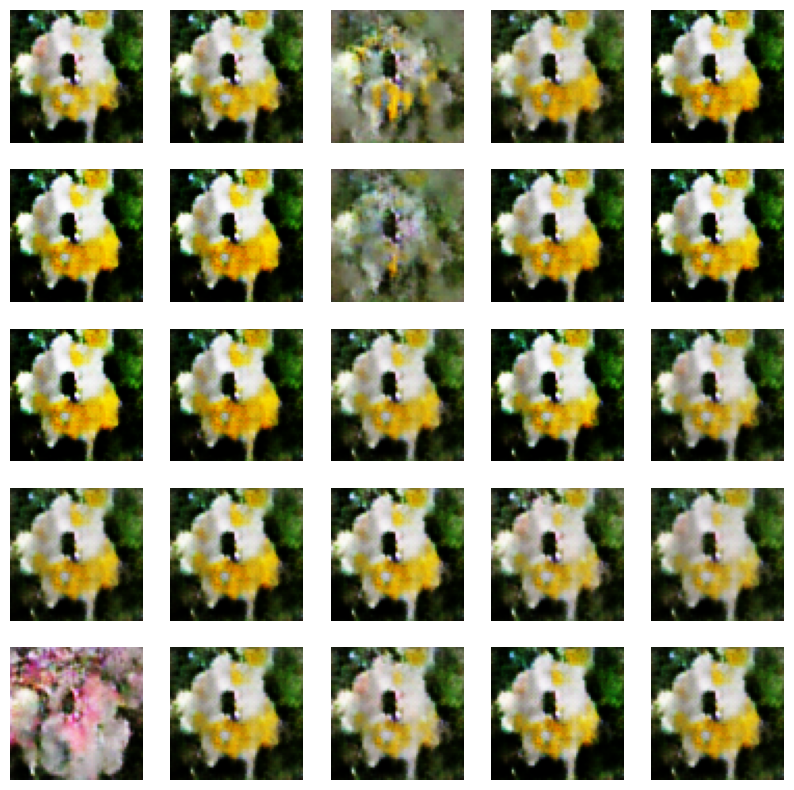

In [23]:
def generate_images(dataloader, source_encoder, generator, num_classes=5, num_images_per_class=5):
    source_encoder.eval()
    generator.eval()

    fig, axes = plt.subplots(num_classes, num_images_per_class, figsize=(10, 10))
    
    with torch.no_grad():
        for i, (images, text_embeddings) in enumerate(dataloader):
            if i >= num_classes:
                break
            
            images = images.to(device)
            text_embeddings = text_embeddings[:, torch.randint(0, 10, (1,)).item(), :].to(device)
            
            source_features = source_encoder(images)
            
            fake_images = generator(source_features, text_embeddings)
            
            for j in range(num_images_per_class):
                axes[i, j].imshow(fake_images[j].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
                axes[i, j].axis("off")
    
    plt.show()

generate_images(test_loader, source_encoder, generator)

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

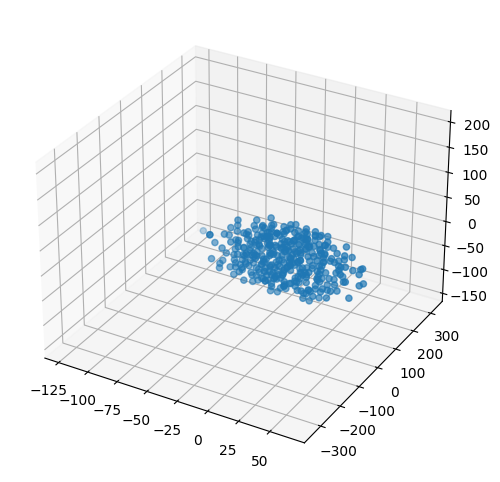

In [24]:
def plot_tsne(source_encoder, dataloader):
    source_encoder.eval()
    
    features, labels = [], []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            source_features = source_encoder(images)
            features.append(source_features.cpu().numpy())
    
    features = np.concatenate(features, axis=0)
    tsne = TSNE(n_components=3, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(features)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2])
    plt.show()

plot_tsne(source_encoder, test_loader)

In [25]:
def model_stats(model, name):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size = sum(p.element_size() * p.numel() for p in model.parameters()) / 1e6  # MB
    print(f"{name}: {total_params} total params, {trainable_params} trainable params, {model_size:.2f} MB")

model_stats(source_encoder, "Source Encoder")
model_stats(generator, "Generator")
model_stats(discriminator, "Discriminator")

Source Encoder: 2756160 total params, 2756160 trainable params, 11.02 MB
Generator: 5000515 total params, 5000515 trainable params, 20.00 MB
Discriminator: 2766657 total params, 2766657 trainable params, 11.07 MB
